In [1]:
import os
from pathlib import Path
print(os.getcwd())
ROOT = Path(os.environ.get("HOME_PROJ_DIR", Path.cwd().resolve().parents[1]))
os.chdir(ROOT)
print(os.getcwd())

/home/fatemeh/thesis/kinodata-3D-affinity-prediction/prob/probing_notebooks
/home/fatemeh/thesis/kinodata-3D-affinity-prediction


In [2]:
# patchy
_ROOT = ROOT

In [3]:
import numpy as np
import pandas as pd
import kinodata.configuration as cfg
from prob.paths_and_io import get_out_dir, load_out_tensor, load_y_by_ids, load_X_from_pt

In [4]:
# this is unnecassary, because I just need the output dir, but maybe in case I need control from args
def get_ds_load_config(**kwargs):
    # default config values
    defaults = dict(
            gnn_model_type="CGNN-3D",
            split_type="random-k-fold",
            filter_rmsd_max_value=2,
            graph_level=True,
            split_index=None,
            dtype_out=None,  # None means no dtype conversion
            device="cpu",
        )
    
    if kwargs.keys() - defaults.keys() != set():
        raise ValueError(f"Invalid arguments: {kwargs.keys() - defaults.keys()}")

    if "gnn_model_type" in kwargs:
        assert kwargs["gnn_model_type"] in ["CGNN-3D", "CGNN", "DTI"], "Invalid GNN model type"
    if "split_type" in kwargs:
        assert kwargs["split_type"] in ["random-k-fold", "scaffold-k-fold", "pocket-k-fold"], "Invalid split type"
    if "filter_rmsd_max_value" in kwargs:
        assert kwargs["filter_rmsd_max_value"] in set({2, 4, 6, 2.00, 4.00, 6.00, None}), "Invalid RMSD threshold"
    if "split_index" in kwargs:
        assert kwargs["split_index"] in set({0, 1, 2, 3, 4, None}), "Invalid split index"
    if "config_name" in kwargs:
        config_name = kwargs["config_name"]
    else:
        config_name = "prob_ds_load"

    # merge: kwargs overrides defaults
    config_args = {**defaults, **kwargs}
    # Initialize the config with the defaults and kwargs
    output_dir = get_out_dir(config_args["gnn_model_type"],
                                config_args["filter_rmsd_max_value"],
                                config_args["split_type"],
                                split_fold=None)
    
    target_dir = output_dir.parents[2] / "targets"

    cfg.register(config_name, **{**config_args, "output_dir": output_dir, "target_dir": target_dir})
    return cfg.get(config_name)

In [5]:
ds_load_config = get_ds_load_config()  # default config
ds_load_config

Config(gnn_model_type=CGNN-3D, split_type=random-k-fold, filter_rmsd_max_value=2, graph_level=True, split_index=None, dtype_out=None, device=cpu, output_dir=/home/famo00001/kinodata-3D-affinity-prediction/data/probing/CGNN-3D/rmsd_cutoff_2/random-k-fold, target_dir=/home/famo00001/kinodata-3D-affinity-prediction/data/probing/targets)

In [6]:
X = load_X_from_pt(ds_load_config.output_dir, layer_num=1)
# y = load_y_by_ids(ds_load_config.output_dir, target_dir=ds_load_config.target_dir, targets_file="nitrogen_counts.pt")
y = load_y_by_ids(ds_load_config.output_dir, target_dir=ds_load_config.target_dir, targets_file="hydrogen_bonds.pt")
print(X.shape, y.shape)

(41238, 256) (41238,)


Now that we have the ouput directory, we can read the corresponding .pt file.

In [7]:
def _cpu_budget(default=16, sub_file=None):
    # 1. Trying scheduler environment variables, based on common conventions
    for key in ("SLURM_CPUS_PER_TASK", "NSLOTS", "OMP_NUM_THREADS"):
        if key in os.environ and os.environ[key].isdigit():
            return int(os.environ[key])

    # 2. parsing the submission file if provided
    if sub_file and Path(sub_file).exists():
        text = Path(sub_file).read_text()
        match = re.search(r"request_CPUs\s*=\s*(\d+)", text, flags=re.I)
        if match:
            return int(match.group(1))

    # 3. Fallback
    return default

_cpu_budget()

16

# Model

In [ ]:
# Dependencies for modeling, plotting, and reporting
import json
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

sns.set(context="notebook", style="whitegrid")


# Reproducibility
RANDOM_STATE = 96
N_SPLITS_CV = 5
TEST_SIZE = 0.1
TARGET = "hydrogen_bonds"
TARGET_FILE = "hydrogen_bonds.pt"  # change per experiment

# Set up experiment directory structure under the probing output dir
def get_exp_dirs(out_root: str | Path, target: str , prob_model: str, layer_num: int) -> dict[str, Path]:
    """Create directories for storing results, figures, and artifacts.
    Experiments are created based on their X, y, and prob model.
    Returns a dict with paths.
    """
    exp_root = Path(out_root)  # e.g. ~/kinodata-3D-affinity-prediction/data/probing/CGNN-3D/rmsd_cutoff_2/random-k-fold
    exp_root = exp_root / target / prob_model / str(layer_num)
    dirs = {
        "root": exp_root,
        "figures": exp_root / "figures",
        "artifacts": exp_root / "artifacts",
        "reports": exp_root / "reports",
    }
    for p in dirs.values():
        p.mkdir(parents=True, exist_ok=True)
    return dirs




def regression_scorers():
    """Common regression scorers for cross-validated model selection."""
    return {
        "r2": make_scorer(r2_score),
        "neg_rmse": make_scorer((lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))), greater_is_better=False),
        "neg_mae": make_scorer(mean_absolute_error, greater_is_better=False),
    }


def evaluate_predictions(y_true, y_pred) -> dict:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"r2": r2, "rmse": rmse, "mae": mae}



def plot_parity(y_true, y_pred, title: str, save_path: Path | None = None):
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.figure(figsize=(6, 6))
    g = sns.JointGrid(x=y_true, y=y_pred, space=0)
    # g.plot(sns.scatterplot, sns.histplot, joint_kws={"alpha": 0.5, "s": 12}, marginal_kws={"bins": 30, "fill": True})
    # same as writing:
    g.plot_joint(sns.scatterplot, alpha=0.5, s=12)
    g.plot_marginals(sns.histplot, bins=30, fill=True)
    g.ax_joint.plot(lims, lims, "r--", linewidth=1)
    g.set_axis_labels("True", "Predicted")
    g.fig.suptitle(title, y=1.02)
    g.ax_joint.set_xlim(lims)
    g.ax_joint.set_ylim(lims)
    if save_path is not None:
        g.fig.savefig(save_path, dpi=200) # dot per inch
    plt.show()


def plot_residuals(y_true, y_pred, title: str, save_path: Path | None = None):
    residuals = y_pred - y_true
    plt.figure(figsize=(5.5, 4))
    sns.histplot(residuals, bins=50, kde=True)
    plt.axvline(0, color="r", linestyle="--", linewidth=1)
    plt.xlabel("Residual (y_pred - y_true)")
    plt.title(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=200) 
    plt.show()


def plot_contours(X, y, model, title: str, save_path: Path | None = None):
    ...




In [9]:
from threadpoolctl import threadpool_limits

def run_cv_search(X, y, prob_model, param_grid: dict, n_splits: int = N_SPLITS_CV, n_jobs: int = 1, exp_dirs: dict | None = None, model_name: str = "model"):
    """Run GridSearchCV with a standard pipeline and return the fitted search, metrics on CV-held out predictions, and store artifacts."""
    if n_jobs == 0:
        n_jobs = _cpu_budget() // 4

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    # Standardize features; target left as-is
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("model", prob_model),
    ])

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    search = GridSearchCV(
        estimator=pipe,
        # estimator=base_estimator,
        param_grid=param_grid,
        scoring=regression_scorers(),
        refit="r2",
        cv=cv,
        n_jobs=n_jobs,
        verbose=1,
        return_train_score=True,
    )

    start = time.time()
    # with threadpool_limits(limits=int(_cpu_budget() // max(n_jobs, 1))):
    # with threadpool_limits(limits=4):
    #     search.fit(X_train, y_train)
    search.fit(X_train, y_train)
    elapsed = time.time() - start

    # Evaluate on held-out set using best estimator
    y_pred = search.best_estimator_.predict(X_test)
    metrics = evaluate_predictions(y_test, y_pred)
    metrics["fit_seconds"] = elapsed

    # Save artifacts
    if exp_dirs is not None:
        # CV results
        cv_df = pd.DataFrame(search.cv_results_)
        cv_df.to_csv(exp_dirs["artifacts"] / f"{model_name}_cv_results.csv", index=False)
        # Best params and metrics summary
        summary = {
            "model": model_name,
            "best_params": search.best_params_,
            "best_score_r2": search.best_score_,
            "metrics_on_unseen_data": metrics,
            "n_samples": int(len(y)),
            "n_test": int(len(y_test)),
            "n_features": int(X.shape[1]),
        }
        with open(exp_dirs["reports"] / f"{model_name}_summary.json", "w") as f:
            json.dump(summary, f, indent=2)
        # Predictions
        pred_df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred})
        pred_df.to_csv(exp_dirs["artifacts"] / f"{model_name}_predictions.csv", index=False)

        # Plots
        plot_parity(y_test, y_pred, title=f"{model_name} Parity (R2={metrics['r2']:.3f})", save_path=exp_dirs["figures"] / f"{model_name}_parity.png")
        plot_residuals(y_test, y_pred, title=f"{model_name} Residuals (RMSE={metrics['rmse']:.3f})", save_path=exp_dirs["figures"] / f"{model_name}_residuals.png")

    return search, metrics, y_pred

In [13]:
# def linear_models(prob_config: cfg.Config, X: np.ndarray, y: np.ndarray, n_jobs: int = _cpu_budget() // 4):
def linear_models(prob_config: cfg.Config, X: np.ndarray, y: np.ndarray, n_jobs: int = 1, target_name: str = TARGET):
    # Define the linear models and their parameter grids
    ridge_grid = {"model__alpha": np.logspace(-5, 4, 10)}
    lasso_grid = {"model__alpha": np.logspace(-5, 1, 7)}
    # enet_grid  = {"model__alpha": np.logspace(-5, 4, 10),
    #             "model__l1_ratio": [0.1, 0.5, 0.9]}


    # target_name = prob_config.target_dir.stem
    layer = prob_config.layer_num

    # Run experiments for each model
    all_runs = []
    for model_name, base, grid in [("ridge", Ridge(random_state=RANDOM_STATE), ridge_grid),
                                    # ("lasso", Lasso(random_state=RANDOM_STATE, max_iter=2000), lasso_grid),
                                    ]:
                                    # ("elasticnet", ElasticNet(random_state=RANDOM_STATE, max_iter=10000), enet_grid)]:
        exp_dirs = get_exp_dirs(prob_config.output_dir, target=target_name, prob_model=model_name, layer_num=layer)
        search, metrics, _ = run_cv_search(X, y, base, grid, n_splits=N_SPLITS_CV, exp_dirs=exp_dirs, n_jobs=n_jobs, model_name=model_name)
        all_runs.append({"experiment": f"{target_name}_{model_name}", "layer": layer, **metrics, **search.best_params_})

    return all_runs



In [14]:
def main(prob_config: cfg.Config):
    # Run experiments across selected layers for linear and non-linear models
    all_runs = []
    # Choose which layer(s) to probe
    layer_nums = [1,2,3]  # e.g., [0,1,2,3] to sweep multiple layers

    # Determine CPU budget
    sub_path = _ROOT / "prob/cluster/"
    sub_file = Path(sub_path / "run_prob.sub")  # change as needed
    # n_jobs = _cpu_budget(sub_file=sub_file) // 4
    n_jobs = 1

    # Load target values
    y = load_y_by_ids(prob_config.output_dir, target_dir=prob_config.target_dir, targets_file=TARGET_FILE)
    target_name = TARGET
    
    for layer in layer_nums:
        X = load_X_from_pt(prob_config.output_dir, layer_num=layer)
        prob_config.update({"layer_num": layer}, allow_duplicates=True)

        # Linear models
        all_runs.extend(linear_models(prob_config, X, y, n_jobs=n_jobs))

        # Non-linear models
        # all_runs.extend(non_linear_models(prob_config, X, y, n_jobs=n_jobs))

        # Aggregate summary across runs per layer
        summary_df = pd.DataFrame(all_runs)
        summary_csv = prob_config.output_dir / target_name / "experiments" / "summary_runs.csv"
        if not summary_csv.parent.exists():
            summary_csv.parent.mkdir(parents=True, exist_ok=True)
        summary_df.to_csv(summary_csv, index=False)
        summary_df.sort_values(["r2"], ascending=False).head(10)

    return all_runs

Fitting 5 folds for each of 10 candidates, totalling 50 fits


<Figure size 600x600 with 0 Axes>

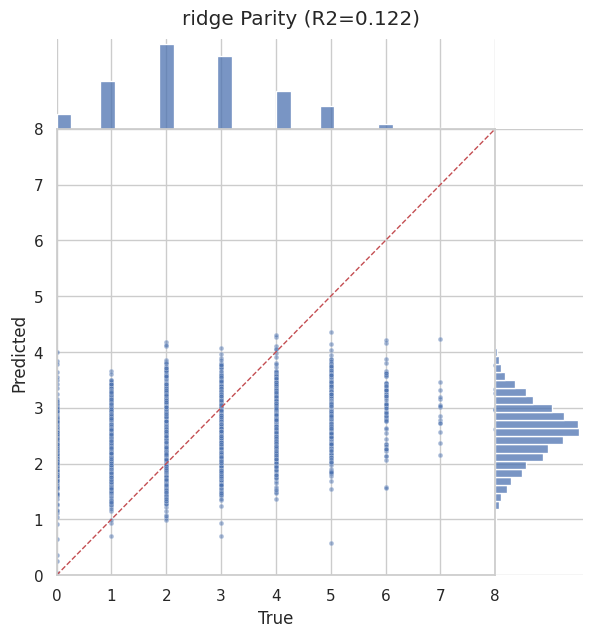

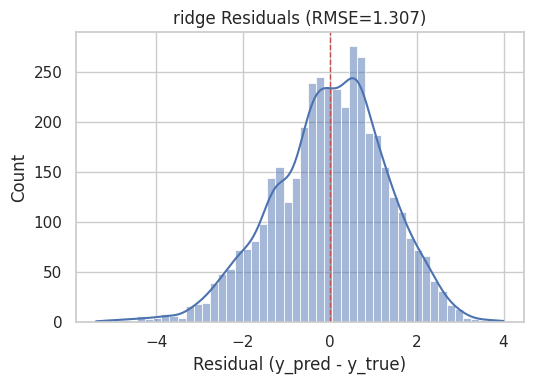

Fitting 5 folds for each of 10 candidates, totalling 50 fits


<Figure size 600x600 with 0 Axes>

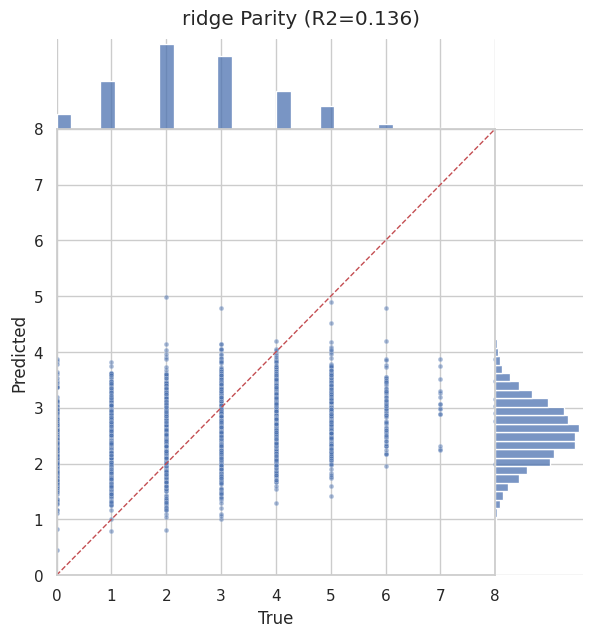

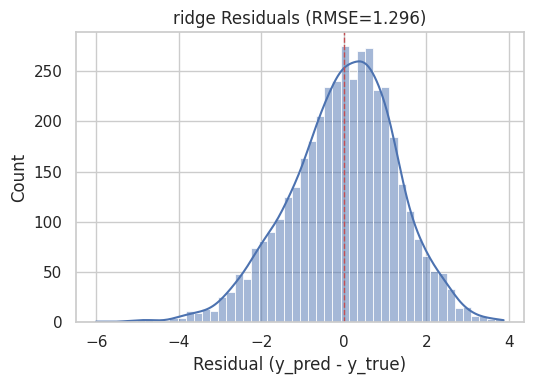

Fitting 5 folds for each of 10 candidates, totalling 50 fits


<Figure size 600x600 with 0 Axes>

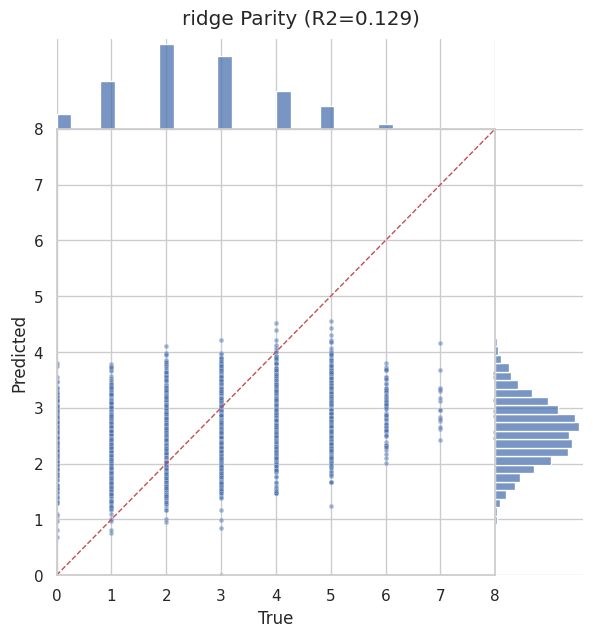

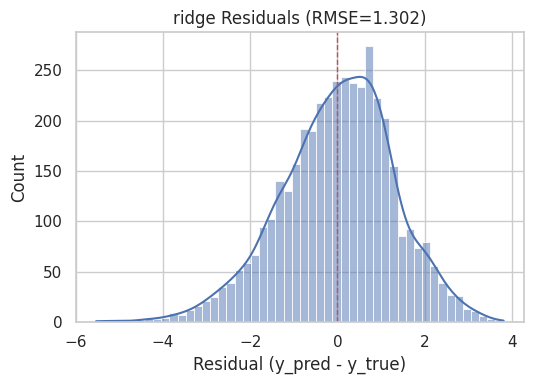

[{'experiment': 'hydrogen_bonds_ridge',
  'layer': 1,
  'r2': 0.12239879369735718,
  'rmse': 1.306612087905117,
  'mae': 1.0347602047120104,
  'fit_seconds': 14.006779670715332,
  'model__alpha': 1.0},
 {'experiment': 'hydrogen_bonds_ridge',
  'layer': 2,
  'r2': 0.1363878846168518,
  'rmse': 1.296156449433904,
  'mae': 1.0214559795148852,
  'fit_seconds': 14.378715515136719,
  'model__alpha': 10.0},
 {'experiment': 'hydrogen_bonds_ridge',
  'layer': 3,
  'r2': 0.12900006771087646,
  'rmse': 1.3016886584523524,
  'mae': 1.026730386524034,
  'fit_seconds': 14.235845804214478,
  'model__alpha': 10.0}]

In [15]:
main(ds_load_config)